In [ ]:
# ==========================================
# Project 8 - Image Classifier with CNN
# Cell 1 - Import Libraries
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("TensorFlow Version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow Version: 2.20.0
Libraries imported successfully!


In [2]:
# ==========================================
# Cell 2 - Load Dataset
# ==========================================

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Dataset loaded successfully!")

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2381s 14us/step
Dataset loaded successfully!
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [3]:
# ==========================================
# Cell 3 - Class Names
# ==========================================

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("Classes:")
for i, name in enumerate(class_names):
    print(i, "=", name)

Classes:
0 = airplane
1 = automobile
2 = bird
3 = cat
4 = deer
5 = dog
6 = frog
7 = horse
8 = ship
9 = truck


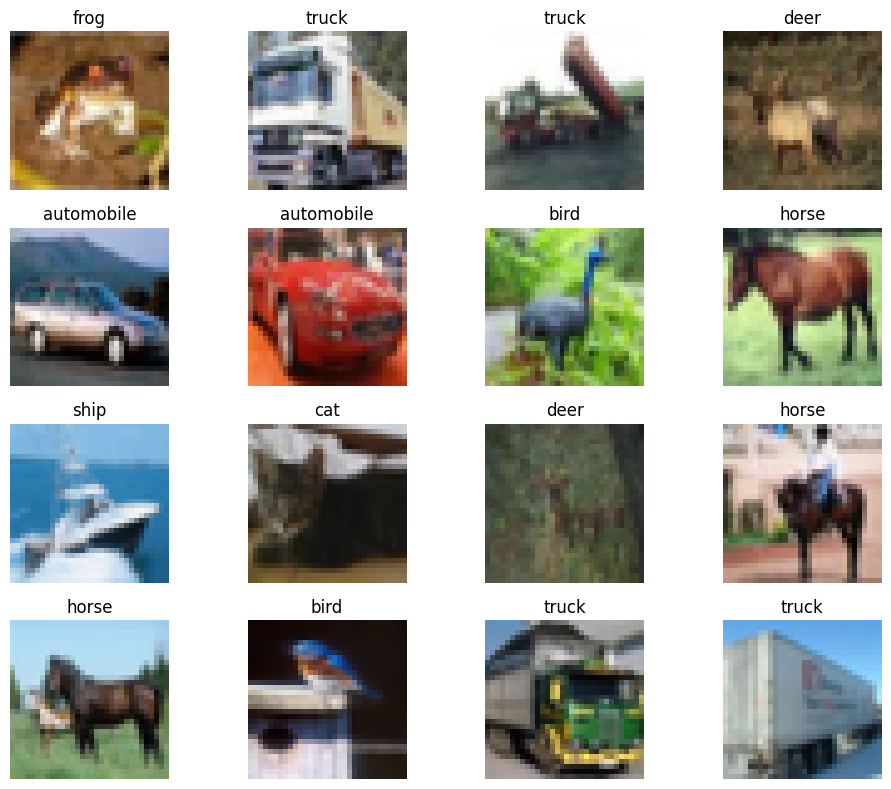

In [4]:
# ==========================================
# Cell 4 - Display Sample Images
# ==========================================

plt.figure(figsize=(10, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(X_train[i])

    label = y_train[i][0]

    plt.title(class_names[label])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# ==========================================
# Cell 5 - Normalize Images
# ==========================================

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Normalization completed!")

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Normalization completed!
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [7]:
# ==========================================
# Cell 6 - Prepare Labels
# ==========================================

y_train = y_train.flatten()
y_test = y_test.flatten()

print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training labels shape: (50000,)
Testing labels shape: (10000,)


In [8]:
# ==========================================
# Cell 7 - Build CNN Model
# ==========================================

model = models.Sequential([

    # Input
    layers.Input(shape=(32, 32, 3)),

    # Convolutional Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Convolutional Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Convolutional Block 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(
        128,
        activation="relu"
    ),

    # Output Layer
    layers.Dense(
        10,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ==========================================
# Cell 8 - Compile CNN
# ==========================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [10]:
# ==========================================
# Cell 9 - Train CNN Model
# ==========================================

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 117ms/step - accuracy: 0.4258 - loss: 1.5704 - val_accuracy: 0.5271 - val_loss: 1.3159
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - accuracy: 0.5727 - loss: 1.2035 - val_accuracy: 0.6049 - val_loss: 1.1180
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 143s 210ms/step - accuracy: 0.6350 - loss: 1.0361 - val_accuracy: 0.6423 - val_loss: 1.0274
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 101s 144ms/step - accuracy: 0.6788 - loss: 0.9151 - val_accuracy: 0.6706 - val_loss: 0.9539
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 114s 99ms/step - accuracy: 0.7074 - loss: 0.8335 - val_accuracy: 0.6782 - val_loss: 0.9110
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 102ms/step - accuracy: 0.7372 - loss: 0.7574 - val_accuracy: 0.6995 - val_loss: 0.8645
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.7578 - loss: 0.6935 - val_accuracy: 0.6977 - val_loss: 0.8827
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.7746 - loss: 

In [12]:
# ==========================================
# Cell 10 - Evaluate Model
# ==========================================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

print(
    f"Test Accuracy: {test_accuracy * 100:.2f}%"
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7167 - loss: 0.8594
Test Loss: 0.8593991994857788
Test Accuracy: 0.71670001745224
Test Accuracy: 71.67%


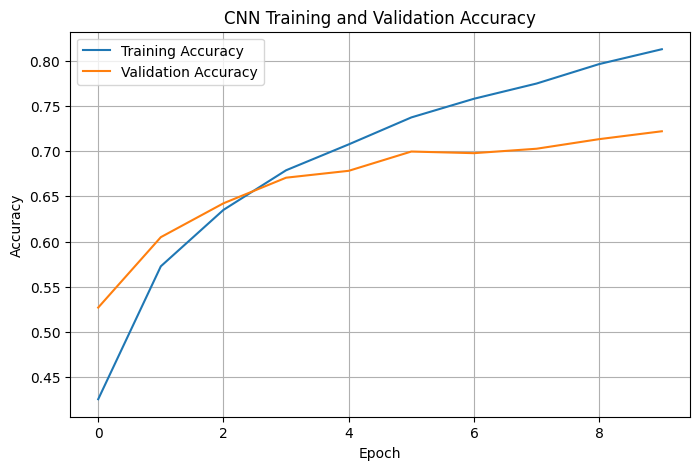

In [13]:
# ==========================================
# Cell 11 - Accuracy Graph
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

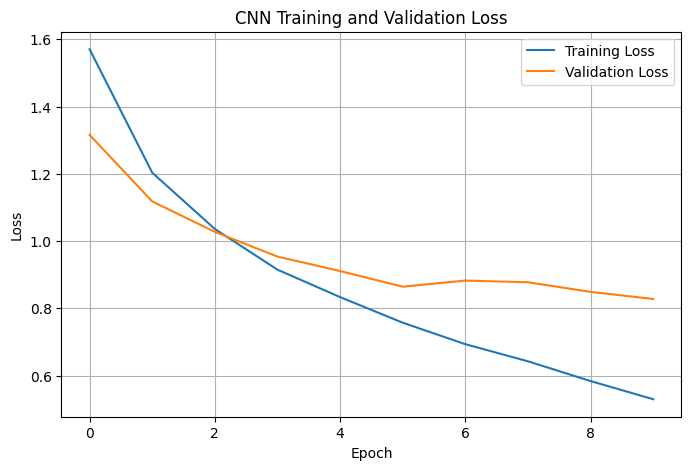

In [14]:
# ==========================================
# Cell 12 - Loss Graph
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

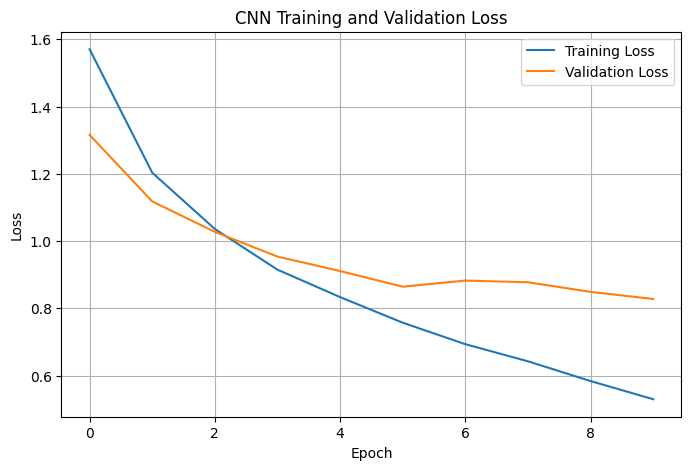

In [15]:
# ==========================================
# Cell 12 - Loss Graph
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [16]:
# ==========================================
# Cell 13 - Generate Predictions
# ==========================================

predictions = model.predict(
    X_test,
    verbose=1
)

predicted_labels = np.argmax(
    predictions,
    axis=1
)

print("Predictions generated successfully!")

print("First 10 predictions:")
print(predicted_labels[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
Predictions generated successfully!
First 10 predictions:
[3 8 8 0 6 6 5 6 3 1]


In [17]:
# ==========================================
# Cell 15 - Classification Report
# ==========================================

report = classification_report(
    y_test,
    predicted_labels,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

    airplane       0.74      0.76      0.75      1000
  automobile       0.85      0.80      0.82      1000
        bird       0.62      0.58      0.60      1000
         cat       0.52      0.55      0.53      1000
        deer       0.72      0.62      0.67      1000
         dog       0.65      0.58      0.61      1000
        frog       0.72      0.85      0.78      1000
       horse       0.76      0.78      0.77      1000
        ship       0.78      0.87      0.82      1000
       truck       0.82      0.79      0.80      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



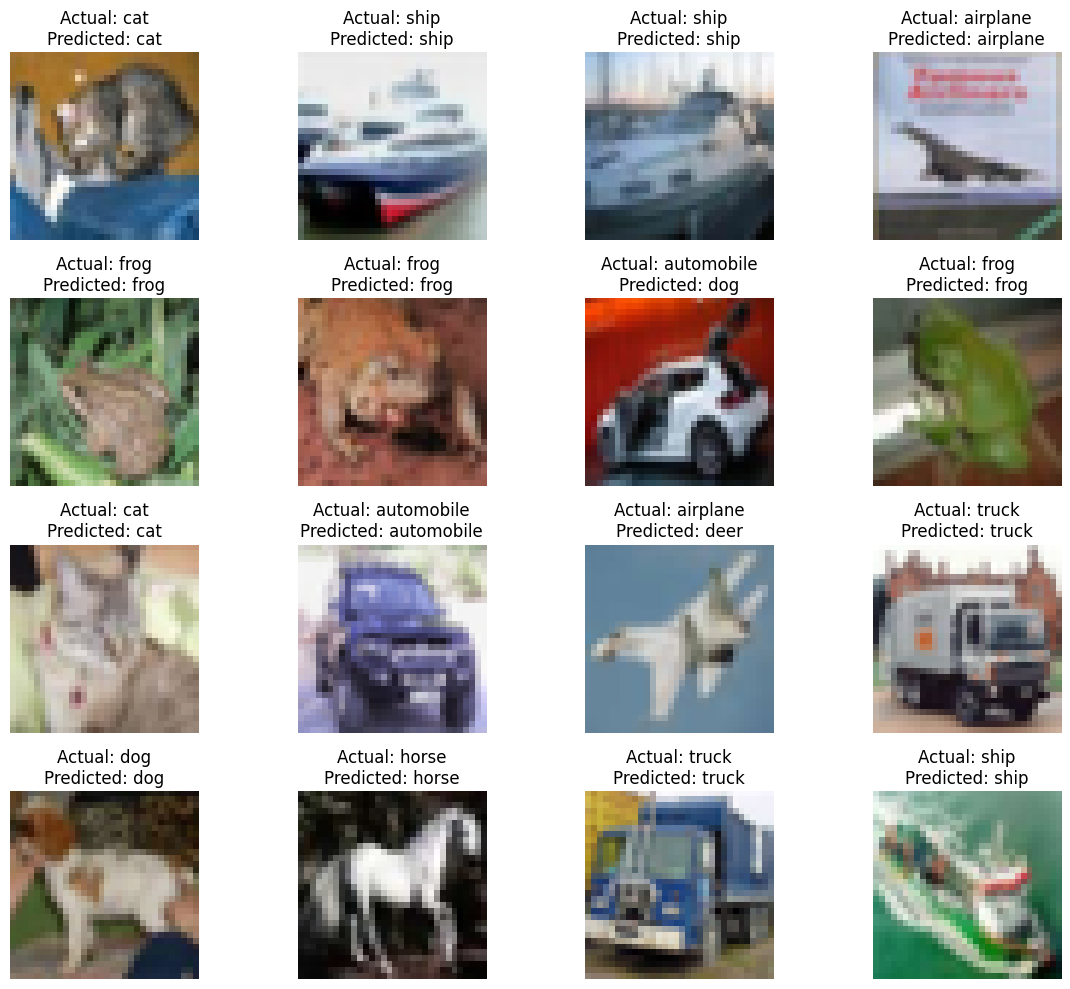

In [18]:
# ==========================================
# Cell 16 - Display Predictions
# ==========================================

plt.figure(figsize=(12, 10))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(X_test[i])

    actual = class_names[y_test[i]]
    predicted = class_names[predicted_labels[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# ==========================================
# Cell 17 - Wrong Prediction Analysis
# ==========================================

wrong_indices = np.where(
    predicted_labels != y_test
)[0]

print(
    "Total wrong predictions:",
    len(wrong_indices)
)

print(
    "Total correct predictions:",
    len(y_test) - len(wrong_indices)
)

Total wrong predictions: 2833
Total correct predictions: 7167


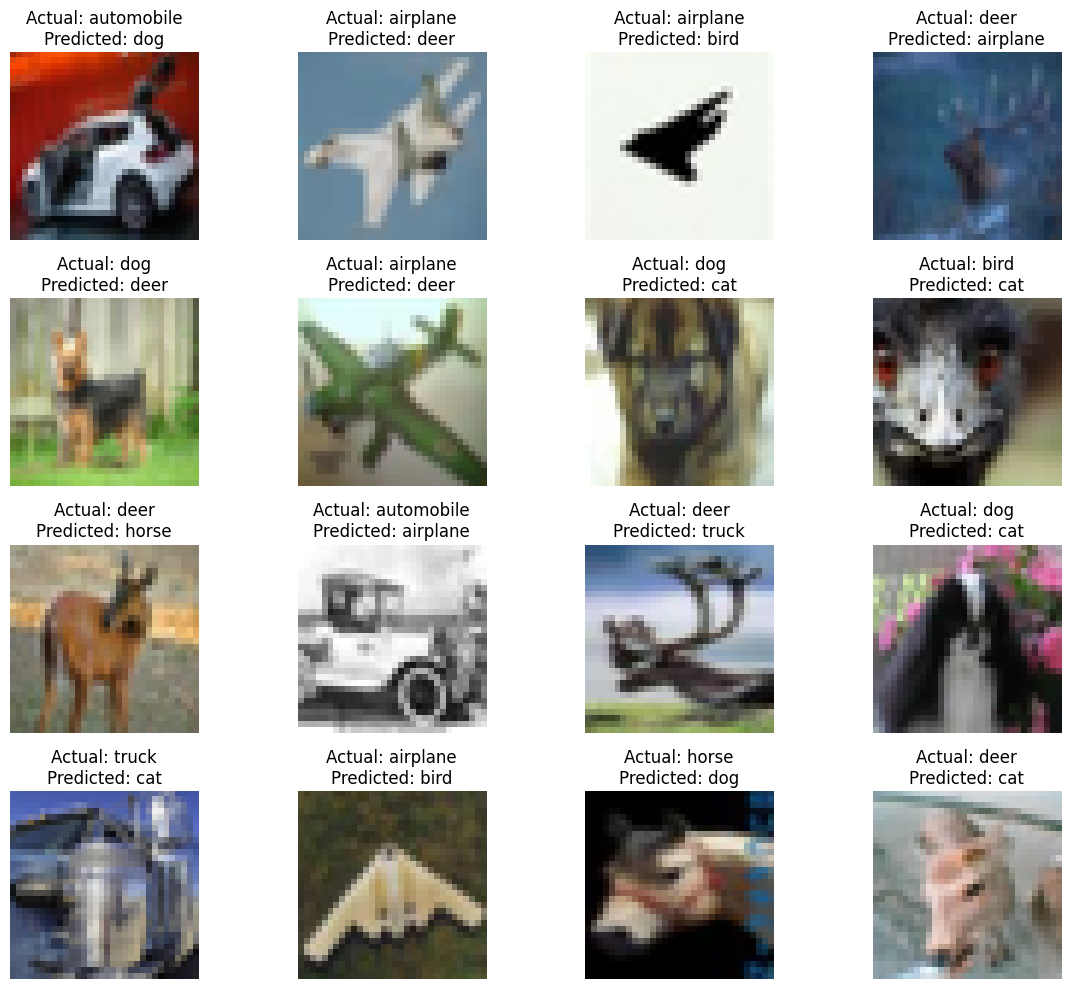

In [20]:
# ==========================================
# Cell 18 - Display Wrong Predictions
# ==========================================

plt.figure(figsize=(12, 10))

number_of_images = min(16, len(wrong_indices))

for i in range(number_of_images):

    index = wrong_indices[i]

    plt.subplot(4, 4, i + 1)

    plt.imshow(X_test[index])

    actual = class_names[y_test[index]]
    predicted = class_names[predicted_labels[index]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
# ==========================================
# Cell 19 - Save CNN Model
# ==========================================

model.save(
    "cifar10_cnn_model.keras"
)

print("Model saved successfully!")

Model saved successfully!


In [22]:
# ==========================================
# Cell 20 - Download Model
# ==========================================

from google.colab import files

files.download(
    "cifar10_cnn_model.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

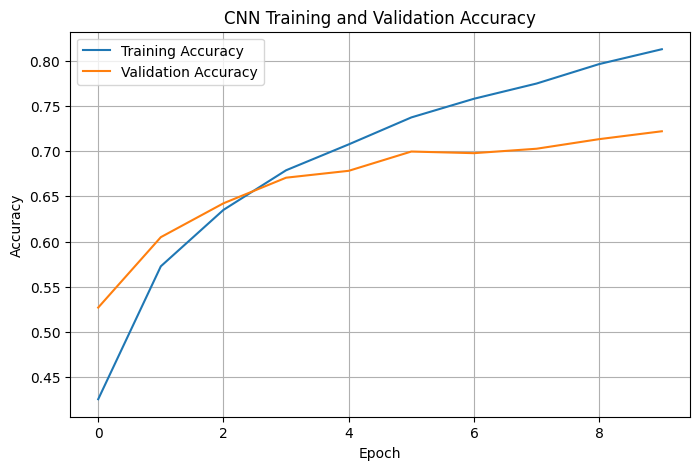

In [23]:
# ==========================================
# Save Accuracy Graph
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.savefig(
    "accuracy_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

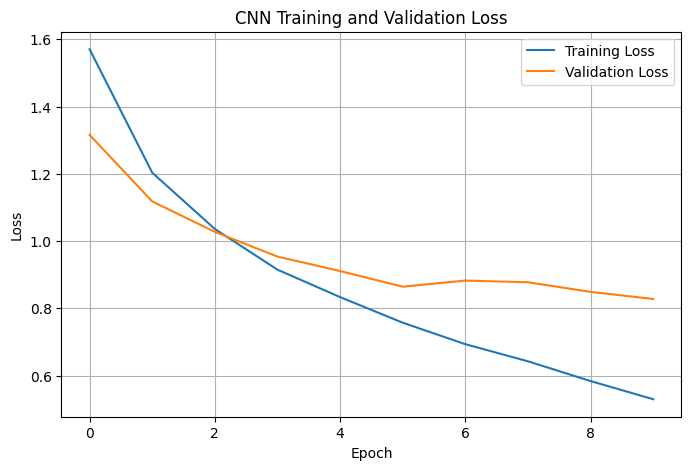

In [24]:
# ==========================================
# Save Loss Graph
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.savefig(
    "loss_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
files.download("loss_plot.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

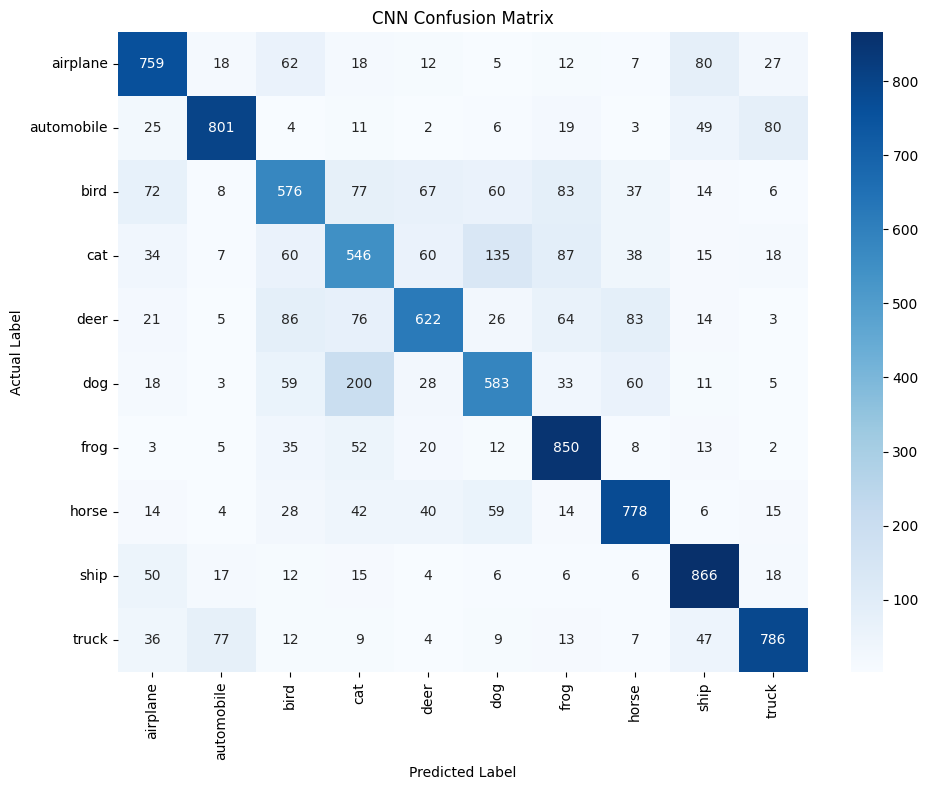

In [28]:
# ==========================================
# Save Confusion Matrix
# ==========================================

# Calculate the confusion matrix
cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>